# CARMS — Phase 4 RL Agent Exploration
Visualise training curves, backtest performance, and agent behaviour.

**Sections**
1. Setup & validation
2. Training curves (Sharpe, return, drawdown per episode)
3. Backtest results vs baselines
4. Agent action distribution per regime
5. Equity curves (portfolio value over time)
6. Trade activity analysis
7. Regime-conditioned behaviour

In [1]:
import os, sys
from pathlib import Path
root = Path(os.getcwd())
for _ in range(5):
    if (root / 'main.py').exists(): break
    root = root.parent
os.chdir(root)
if str(root) not in sys.path: sys.path.insert(0, str(root))
print(f'Root: {root}')

Root: C:\Users\Mugithi\Documents\carms


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import torch
warnings.filterwarnings('ignore')
Path('logs').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.3,
    'axes.spines.top':False,'axes.spines.right':False,'font.size':10
})

from src.utils.logger import load_config
from src.agents.phase4_runner import validate_phase4
from src.agents.backtester import _sharpe, _max_drawdown
from src.regime.hmm_detector import load_regime_labels, REGIME_COLOURS

config = load_config('configs/config.yaml')
config['_base_dir'] = str(root)
for key in ['raw_dir','processed_dir','charts_dir']:
    config['data'][key] = str((root/config['data'][key]).resolve())
MODEL_DIR = str(root / 'models')

AGENT_COLOURS = {'forex':'#378ADD','crypto':'#F7931A','gold':'#D4AF37'}
RCOLOURS = {
    'trending_up':'#1D9E75','trending_down':'#E24B4A',
    'ranging':'#B4B2A9','crisis':'#D85A30'
}
print('✓ Ready')

✓ Ready


## 1 — Validation report

In [3]:
validate_phase4(config, MODEL_DIR)


────────────────────────────────────────────────────────────
  CARMS Phase 4 — Validation Report
────────────────────────────────────────────────────────────

  Agent Checkpoints
    ✓ Forex  (PPO)     ppo_forex.pt  (0.8 MB)
    ✓ Crypto (SAC)     sac_crypto.pt  (2.1 MB)
    ✓ Gold   (PPO)     ppo_gold.pt  (0.8 MB)

  Training Metrics
    ✓ forex    metrics  last50ep: sharpe=-0.49  ret=-7.4%
    ✓ crypto   metrics  last50ep: sharpe=-1.84  ret=+6.3%
    ✓ gold     metrics  last50ep: sharpe=-0.74  ret=-0.5%

  Backtest Results
    ✓ backtest_results.csv  (5 agent-symbol pairs)
       forex      EURUSD=X       return=-1.0%  sharpe=-0.40
       forex      KES=X          return=+13.1%  sharpe=1.77
       crypto     BTC-USD        return=+2708.5%  sharpe=2.38
       crypto     ETH-USD        return=+13.1%  sharpe=0.44
       gold       GC=F           return=+40.8%  sharpe=0.58

  Paper Trading Readiness
    ✓ All agents trained — ready for paper trading!
    Connect to Binance Testnet (cryp

True

## 2 — Training curves

In [4]:
from src.agents.trainer import AGENT_CONFIGS

metrics_files = {
    'forex':  Path(MODEL_DIR) / 'ppo_forex_metrics.csv',
    'crypto': Path(MODEL_DIR) / 'sac_crypto_metrics.csv',
    'gold':   Path(MODEL_DIR) / 'ppo_gold_metrics.csv',
}

agent_metrics = {}
for name, path in metrics_files.items():
    if path.exists():
        df = pd.read_csv(path)
        agent_metrics[name] = df
        print(f'{name:<8}: {len(df):,} episodes  '
              f'final sharpe={df["sharpe"].tail(50).mean():.2f}  '
              f'final return={df["total_return"].tail(50).mean():+.1%}')
    else:
        print(f'{name:<8}: no metrics file yet')

forex   : 600 episodes  final sharpe=-0.49  final return=-7.4%
crypto  : 600 episodes  final sharpe=-1.84  final return=+6.3%
gold    : 600 episodes  final sharpe=-0.74  final return=-0.5%


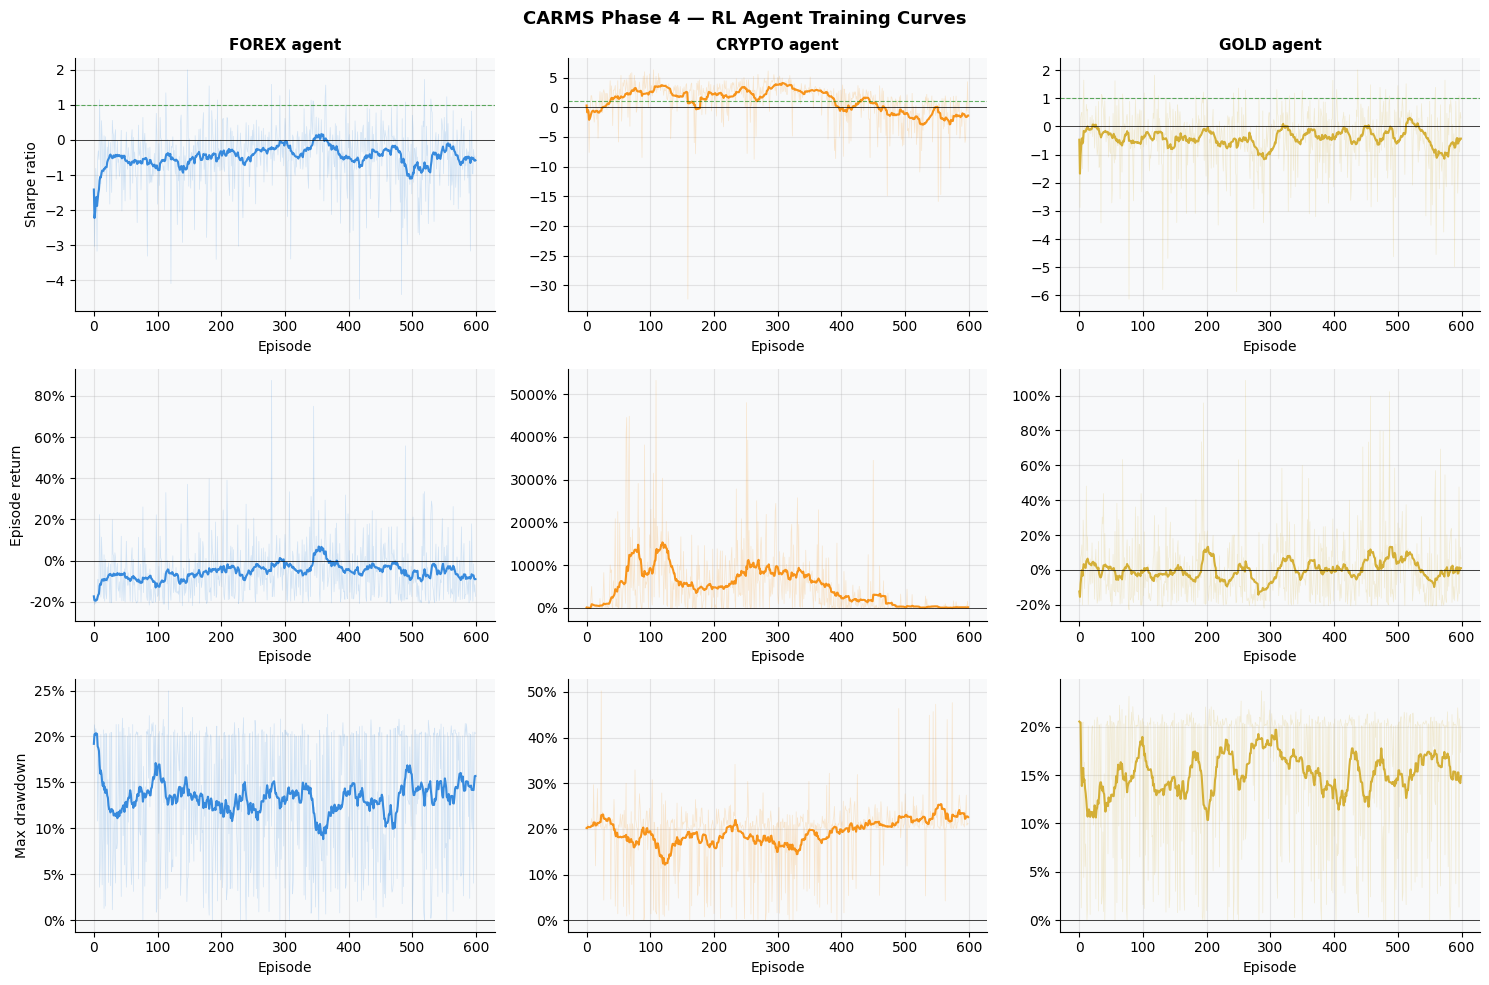

Saved → logs/p4_01_training_curves.png


In [5]:
if agent_metrics:
    fig, axes = plt.subplots(3, len(agent_metrics), figsize=(5*len(agent_metrics), 10))
    if len(agent_metrics) == 1:
        axes = axes.reshape(-1, 1)

    metrics_to_plot = [
        ('sharpe',        'Sharpe ratio',       0),
        ('total_return',  'Episode return',      1),
        ('max_drawdown',  'Max drawdown',        2),
    ]

    for col, (name, df) in enumerate(agent_metrics.items()):
        colour = AGENT_COLOURS.get(name, '#7F77DD')
        for (metric, label, row) in metrics_to_plot:
            ax    = axes[row, col]
            vals  = df[metric].values
            # Rolling mean for smoothing
            roll  = pd.Series(vals).rolling(20, min_periods=1).mean().values
            ax.plot(vals,  color=colour, alpha=0.2, linewidth=0.5)
            ax.plot(roll,  color=colour, linewidth=1.5, label='20-ep MA')
            ax.axhline(0,  color='black', linewidth=0.5)
            if metric == 'sharpe':
                ax.axhline(1.0, color='green', linestyle='--',
                            linewidth=0.8, alpha=0.6, label='Sharpe=1')
            if row == 0:
                ax.set_title(f'{name.upper()} agent', fontweight='bold', fontsize=11)
            if col == 0:
                ax.set_ylabel(label)
            ax.set_xlabel('Episode')
            if metric == 'total_return':
                ax.yaxis.set_major_formatter(
                    plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
            if metric == 'max_drawdown':
                ax.yaxis.set_major_formatter(
                    plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

    plt.suptitle('CARMS Phase 4 — RL Agent Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p4_01_training_curves.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved → logs/p4_01_training_curves.png')

## 3 — Backtest results vs baselines

In [6]:
bt_path = Path(MODEL_DIR) / 'backtest_results.csv'
bl_path = Path(MODEL_DIR) / 'baseline_comparison.csv'

bt_df = pd.read_csv(bt_path) if bt_path.exists() else None
bl_df = pd.read_csv(bl_path) if bl_path.exists() else None

if bt_df is not None:
    print('Backtest Results')
    print('='*70)
    print(bt_df.to_string(index=False))
else:
    print('No backtest results yet — run: python main.py --phase 4')

Backtest Results
 agent   symbol  total_return_%  sharpe  sortino  max_drawdown_%  n_trades  win_rate_%  avg_position  final_value_$  vs_buyhold_%
 forex EURUSD=X           -1.04  -0.404   -0.531            2.02       982        48.0         0.058        9896.36          6.11
 forex    KES=X           13.11   1.774    2.097            1.52      1155        47.3         0.075       11311.37        -16.94
crypto  BTC-USD         2708.51   2.376    3.973           20.49       754        56.0         0.559      280850.71        461.38
crypto  ETH-USD           13.10   0.441    0.809           22.41       150        48.7         0.611       11310.28      -2196.14
  gold     GC=F           40.83   0.583    0.707           15.06      1078        50.2         0.558       14083.23        -60.66


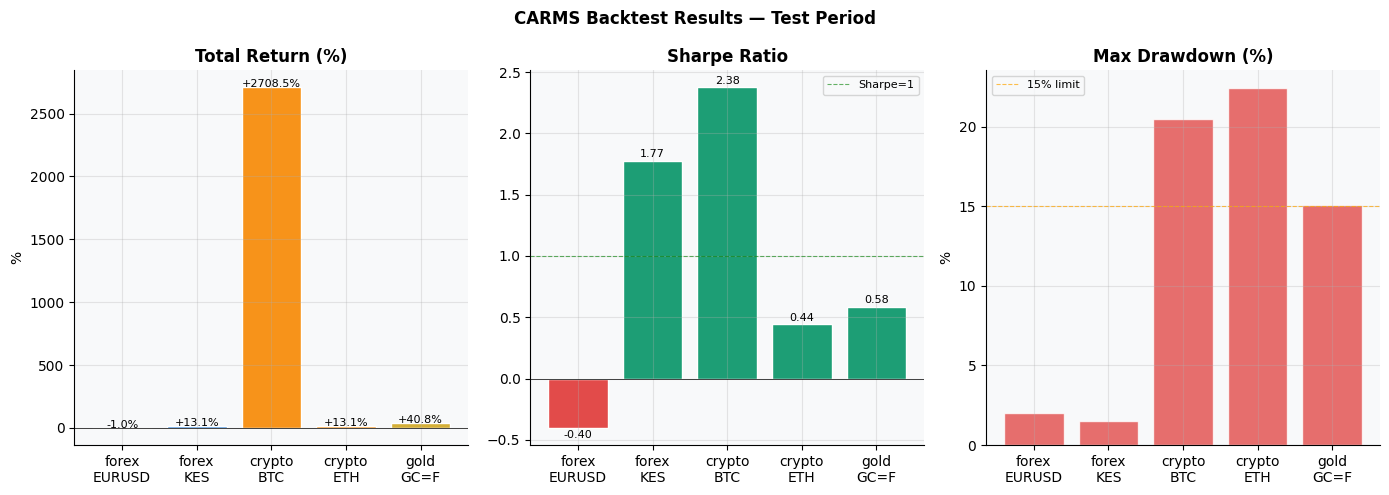

In [7]:
if bt_df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # Total return comparison
    ax = axes[0]
    colours = [AGENT_COLOURS.get(r['agent'],'#888') for _,r in bt_df.iterrows()]
    bars = ax.bar(
        [f"{r['agent']}\n{r['symbol'].replace('=X','').replace('-USD','')}"
         for _,r in bt_df.iterrows()],
        bt_df['total_return_%'], color=colours, edgecolor='white'
    )
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title('Total Return (%)', fontweight='bold')
    ax.set_ylabel('%')
    for bar, v in zip(bars, bt_df['total_return_%']):
        ax.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+(1 if v>=0 else -2),
                 f'{v:+.1f}%', ha='center', fontsize=8)

    # Sharpe ratio comparison
    ax2 = axes[1]
    bars2 = ax2.bar(
        [f"{r['agent']}\n{r['symbol'].replace('=X','').replace('-USD','')}"
         for _,r in bt_df.iterrows()],
        bt_df['sharpe'],
        color=[('#1D9E75' if v>0 else '#E24B4A') for v in bt_df['sharpe']],
        edgecolor='white'
    )
    ax2.axhline(0,   color='black', linewidth=0.5)
    ax2.axhline(1.0, color='green', linestyle='--', linewidth=0.8, alpha=0.6, label='Sharpe=1')
    ax2.set_title('Sharpe Ratio', fontweight='bold')
    ax2.legend(fontsize=8)
    for bar, v in zip(bars2, bt_df['sharpe']):
        ax2.text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+(0.03 if v>=0 else -0.08),
                  f'{v:.2f}', ha='center', fontsize=8)

    # Max drawdown
    ax3 = axes[2]
    ax3.bar(
        [f"{r['agent']}\n{r['symbol'].replace('=X','').replace('-USD','')}"
         for _,r in bt_df.iterrows()],
        bt_df['max_drawdown_%'],
        color='#E24B4A', edgecolor='white', alpha=0.8
    )
    ax3.axhline(15, color='orange', linestyle='--', linewidth=0.8,
                 label='15% limit', alpha=0.7)
    ax3.set_title('Max Drawdown (%)', fontweight='bold')
    ax3.set_ylabel('%')
    ax3.legend(fontsize=8)

    plt.suptitle('CARMS Backtest Results — Test Period', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p4_02_backtest.png', dpi=130, bbox_inches='tight')
    plt.show()

## 4 — Equity curves

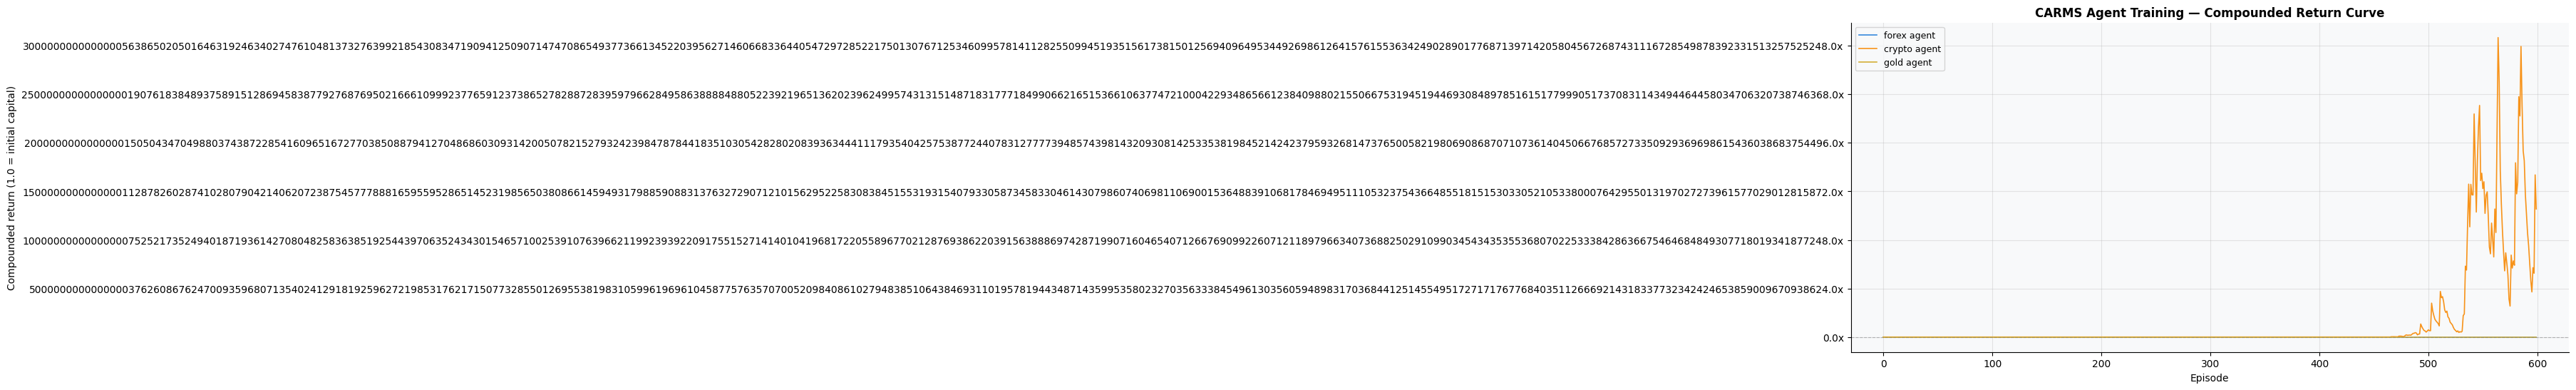

In [8]:
# Reconstruct equity curves from training metrics
if agent_metrics:
    fig, ax = plt.subplots(figsize=(13, 6))

    for name, df in agent_metrics.items():
        colour = AGENT_COLOURS.get(name, '#888')
        # Cumulative return across episodes (compound)
        cum_ret = (1 + df['total_return']).cumprod()
        ax.plot(cum_ret.values, color=colour, linewidth=1.2, label=f'{name} agent')

    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Compounded return (1.0 = initial capital)')
    ax.set_title('CARMS Agent Training — Compounded Return Curve', fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}x'))
    plt.tight_layout()
    plt.savefig('logs/p4_03_equity_curves.png', dpi=130, bbox_inches='tight')
    plt.show()

## 5 — Trade activity analysis

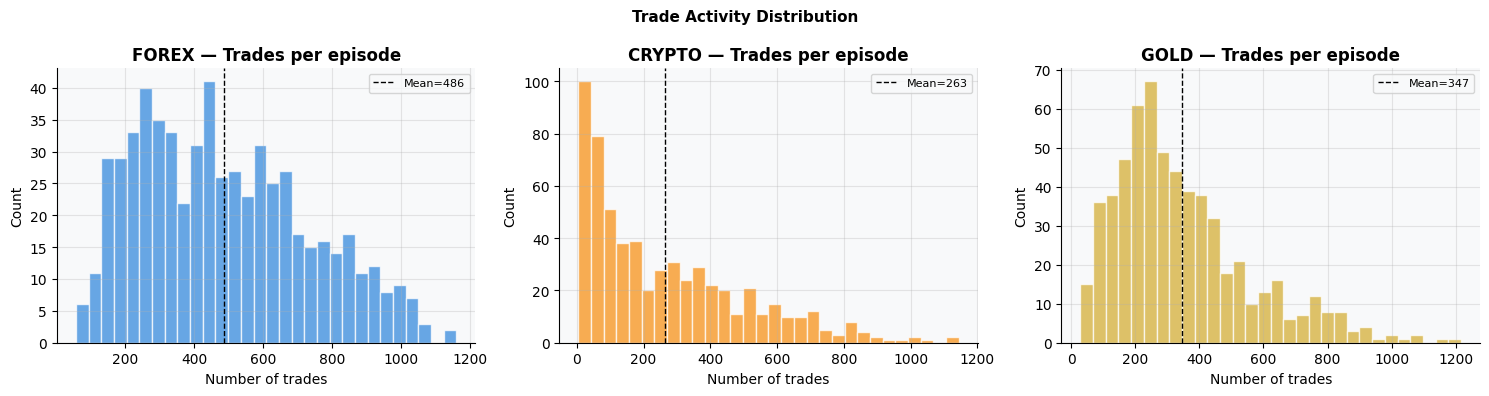

Trade Activity Summary (last 100 episodes):
  forex     : avg 405 trades/ep  win_rate=27%
  crypto    : avg 101 trades/ep  win_rate=35%
  gold      : avg 239 trades/ep  win_rate=43%


In [9]:
if agent_metrics:
    fig, axes = plt.subplots(1, len(agent_metrics), figsize=(5*len(agent_metrics), 4))
    if len(agent_metrics) == 1: axes = [axes]

    for ax, (name, df) in zip(axes, agent_metrics.items()):
        colour = AGENT_COLOURS.get(name, '#888')
        # n_trades distribution
        ax.hist(df['n_trades'], bins=30, color=colour, alpha=0.75, edgecolor='white')
        ax.axvline(df['n_trades'].mean(), color='black', linestyle='--',
                    linewidth=1, label=f'Mean={df["n_trades"].mean():.0f}')
        ax.set_title(f'{name.upper()} — Trades per episode', fontweight='bold')
        ax.set_xlabel('Number of trades')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)

    plt.suptitle('Trade Activity Distribution', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p4_04_trade_activity.png', dpi=130, bbox_inches='tight')
    plt.show()

    # Summary stats
    print('Trade Activity Summary (last 100 episodes):')
    print('='*55)
    for name, df in agent_metrics.items():
        last = df.tail(100)
        print(f'  {name:<10}: avg {last["n_trades"].mean():.0f} trades/ep  '
              f'win_rate={last["total_return"].gt(0).mean():.0%}')

## 6 — Regime-conditioned performance

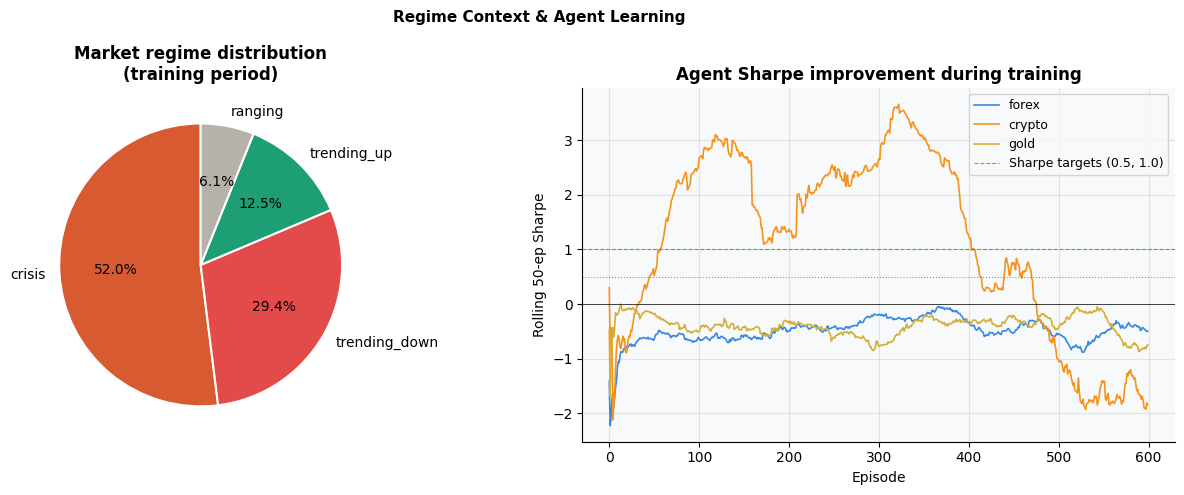

In [10]:
# Cross-reference episode performance with regime prevalence
labels_df = load_regime_labels(MODEL_DIR)

if labels_df is not None and agent_metrics:
    # Get dominant regime per date window
    regime_counts = labels_df['regime_name'].value_counts(normalize=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Regime distribution pie
    colours_pie = [RCOLOURS.get(n,'#888') for n in regime_counts.index]
    axes[0].pie(
        regime_counts.values,
        labels=regime_counts.index,
        colors=colours_pie,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5}
    )
    axes[0].set_title('Market regime distribution\n(training period)', fontweight='bold')

    # Sharpe rolling average over training
    for name, df in agent_metrics.items():
        colour = AGENT_COLOURS.get(name, '#888')
        roll   = df['sharpe'].rolling(50, min_periods=1).mean()
        axes[1].plot(roll.values, color=colour, linewidth=1.2, label=name)

    axes[1].axhline(0,   color='black', linewidth=0.5)
    axes[1].axhline(0.5, color='green', linestyle=':', linewidth=0.8, alpha=0.6)
    axes[1].axhline(1.0, color='green', linestyle='--', linewidth=0.8, alpha=0.6,
                     label='Sharpe targets (0.5, 1.0)')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Rolling 50-ep Sharpe')
    axes[1].set_title('Agent Sharpe improvement during training', fontweight='bold')
    axes[1].legend(fontsize=9)

    plt.suptitle('Regime Context & Agent Learning', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p4_05_regime_performance.png', dpi=130, bbox_inches='tight')
    plt.show()

## 7 — Phase 4 summary

In [11]:
print('CARMS Phase 4 — Training Summary')
print('='*60)

for name, df in agent_metrics.items():
    last  = df.tail(50)
    best  = df.loc[df['sharpe'].idxmax()]
    print(f'\n  {name.upper()} Agent')
    print(f'    Algorithm     : {"PPO" if name != "crypto" else "SAC"}')
    print(f'    Total episodes: {len(df):,}')
    print(f'    Best Sharpe   : {df["sharpe"].max():.2f}  (episode {int(best["episode"])})')
    print(f'    Last 50ep avg : sharpe={last["sharpe"].mean():.2f}  '
          f'return={last["total_return"].mean():+.1%}  '
          f'dd={last["max_drawdown"].mean():.1%}')

print()
checkpoints = list(Path(MODEL_DIR).glob('ppo_*.pt')) + list(Path(MODEL_DIR).glob('sac_*.pt'))
print(f'  Checkpoints saved: {len(checkpoints)}')
for c in sorted(checkpoints):
    print(f'    {c.name}  ({c.stat().st_size/1e6:.1f} MB)')

print()
print('Next: python main.py --phase 5')
print('Phase 5 trains the meta-controller that coordinates all three agents')
print('and adds the portfolio risk manager with position sizing + circuit breakers.')

CARMS Phase 4 — Training Summary

  FOREX Agent
    Algorithm     : PPO
    Total episodes: 600
    Best Sharpe   : 2.00  (episode 148)
    Last 50ep avg : sharpe=-0.49  return=-7.4%  dd=14.6%

  CRYPTO Agent
    Algorithm     : SAC
    Total episodes: 600
    Best Sharpe   : 6.32  (episode 106)
    Last 50ep avg : sharpe=-1.84  return=+6.3%  dd=22.5%

  GOLD Agent
    Algorithm     : PPO
    Total episodes: 600
    Best Sharpe   : 2.01  (episode 438)
    Last 50ep avg : sharpe=-0.74  return=-0.5%  dd=15.8%

  Checkpoints saved: 6
    ppo_forex.pt  (0.8 MB)
    ppo_forex_final.pt  (0.8 MB)
    ppo_gold.pt  (0.8 MB)
    ppo_gold_final.pt  (0.8 MB)
    sac_crypto.pt  (2.1 MB)
    sac_crypto_final.pt  (2.1 MB)

Next: python main.py --phase 5
Phase 5 trains the meta-controller that coordinates all three agents
and adds the portfolio risk manager with position sizing + circuit breakers.


## ✅ Phase 4 complete

```bash
python main.py --phase 5   # Next: meta-controller + paper trading
```

**What Phase 5 adds:**
- RL meta-controller that routes between Forex / Crypto / Gold agents
- Portfolio risk manager (Kelly sizing, 15% drawdown circuit breaker)
- Paper trading connector (Binance Testnet + OANDA demo)
- Live performance dashboard